In [ ]:
#importamos librerias y dependencias y las configuraciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

#opciones para la visualizacion de las tablas
pd.set_option('display.max_columns', None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

#configuracion de graficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#gestion de warning
warnings.filterwarnings('ignore')

print("Configuración del entorno\n")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

Configuración del entorno

Pandas: 2.2.2
Numpy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2


In [ ]:
#conectamos con DRIVE para cargar el dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Ruta de acceso del dataset
project_folder_path = '/content/drive/MyDrive/PROYECTO TFM IA_BG_E1'

#dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_ramon_v02_regresion_ventas.csv'

#dataset = '/content/sample_data/data_v07_con_fechas_regresion_ventas.csv'

dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_v07_con_fechas_regresion_ventas.csv'


In [ ]:
#cargamos el dataset y mostramos las primeras filas
try:
    df = pd.read_csv(dataset, encoding="ISO-8859-1")
    print(f"Archivo {dataset} cargado exitosamente.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {dataset}")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Archivo /content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_v07_con_fechas_regresion_ventas.csv cargado exitosamente.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,1,12,2010,8,2,1,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,1,12,2010,8,2,1,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34


In [ ]:
#Vista general del dataset

#Dimensiones de dataset
print("Dimensiones del dataset:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

#Nombres de las columnas.
print("\nNombres de las columnas:")
print(df.columns)

#Primeras y ultimas 5 filas del dataset
print("\nPrimeras 5 filas del dataset:")
display(df.head())
print("\nUltimas 5 filas del dataset:")
display(df.tail())

#tipos de datos y estructura
print("\nTipos de datos y estructura del dataset:")
display(df.info())

#resumen estadistico
print("\nResumen estadístico del dataset:")
display(df.describe())

#resumen descriptivo
print("\nResumen descriptivo del dataset:")
display(df.describe(include='object'))



Dimensiones del dataset:
Filas: 522010
Columnas: 15

Nombres de las columnas:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country',
       'InvoiceDay', 'InvoiceMonth', 'InvoiceYear', 'InvoiceHour', 'DayOfWeek', 'IsUk', 'TotalPrice'],
      dtype='object')

Primeras 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,1,12,2010,8,2,1,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,1,12,2010,8,2,1,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34



Ultimas 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
522005,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,"12,680.00",France,9,12,2011,12,4,0,10.20
522006,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,"12,680.00",France,9,12,2011,12,4,0,12.60
522007,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,"12,680.00",France,9,12,2011,12,4,0,16.60
522008,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,"12,680.00",France,9,12,2011,12,4,0,16.60
522009,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,"12,680.00",France,9,12,2011,12,4,0,14.85



Tipos de datos y estructura del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522010 entries, 0 to 522009
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   InvoiceNo     522010 non-null  int64  
 1   StockCode     522010 non-null  object 
 2   Description   522010 non-null  object 
 3   Quantity      522010 non-null  int64  
 4   InvoiceDate   522010 non-null  object 
 5   UnitPrice     522010 non-null  float64
 6   CustomerID    390600 non-null  float64
 7   Country       522010 non-null  object 
 8   InvoiceDay    522010 non-null  int64  
 9   InvoiceMonth  522010 non-null  int64  
 10  InvoiceYear   522010 non-null  int64  
 11  InvoiceHour   522010 non-null  int64  
 12  DayOfWeek     522010 non-null  int64  
 13  IsUk          522010 non-null  int64  
 14  TotalPrice    522010 non-null  float64
dtypes: float64(3), int64(8), object(4)
memory usage: 59.7+ MB


None


Resumen estadístico del dataset:


,InvoiceNo,Quantity,UnitPrice,CustomerID,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
count,"522,010.00","522,010.00","522,010.00","390,600.00","522,010.00","522,010.00","522,010.00","522,010.00","522,010.00","522,010.00","522,010.00"
mean,"559,962.20",10.32,3.27,"15,295.82",15.02,7.55,"2,010.92",13.08,2.43,0.92,19.09
std,"13,422.16",37.81,4.38,"1,710.32",8.66,3.51,0.27,2.44,1.85,0.28,84.60
min,"536,365.00",1.00,0.00,"12,347.00",1.00,1.00,"2,010.00",6.00,0.00,0.00,0.00
25%,"547,906.00",1.00,1.25,"13,969.00",7.00,5.00,"2,011.00",11.00,1.00,1.00,3.90
50%,"560,690.00",4.00,2.08,"15,159.00",15.00,8.00,"2,011.00",13.00,2.00,1.00,9.90
75%,"571,824.00",12.00,4.13,"16,794.00",22.00,11.00,"2,011.00",15.00,4.00,1.00,17.70
max,"581,587.00","4,800.00",649.50,"18,287.00",31.00,12.00,"2,011.00",20.00,6.00,1.00,"38,970.00"



Resumen descriptivo del dataset:


,StockCode,Description,InvoiceDate,Country
count,522010,522010,522010,522010
unique,3912,4017,18288,38
top,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2011-10-31 14:41:00,United Kingdom
freq,2252,2310,1113,478466


In [ ]:
# Getting the number of rows in the dataframe
df.shape[0]

522010

# Preprocesado y transformación de datos

necesitamos transformar el dataset de transacciones individuales en un dataset de ventas diarias antes de entrenar cualquier modelo.

Aquí tienes la estrategia y el código para preparar los datos y ejecutar el benchmark final:

**1. Preparación del Dataset Diario (Agregación)**

Primero, debemos convertir las miles de filas de transacciones en una serie de aproximadamente **374 puntos** (los días que hay entre diciembre 2010 y diciembre 2011).


In [ ]:
print("\n--- 1. PREPARACIÓN DE DATOS DIARIOS Y FEATURE ENGINEERING ---")

# Rangos exactos (igual que Prophet)
start_train = '2010-12-01'
end_train   = '2011-11-08'
start_val   = '2011-10-09'
end_val     = '2011-11-08'
start_test  = '2011-11-09'
end_test    = '2011-12-09'

def preprocess_for_all_models(df, target_col='TotalPrice'):
    # 1. Agregación Diaria
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']).dt.normalize()
    df_daily = df.groupby('InvoiceDate')[target_col].sum().reset_index()
    df_daily.columns = ['date', 'daily_sales']

    # FEATURE ENGINEERING
    # Extraemos componentes de la fecha
    df_daily['month'] = df_daily['date'].dt.month
    df_daily['day_of_month'] = df_daily['date'].dt.day
    df_daily['day_of_week'] = df_daily['date'].dt.dayofweek
    df_daily['is_weekend'] = (df_daily['day_of_week'] >= 5).astype(int)

    # Variables de "Memoria" (Lags)
    df_daily['sales_lag_1'] = df_daily['daily_sales'].shift(1)
    df_daily['sales_lag_7'] = df_daily['daily_sales'].shift(7)

    # Medias móviles y tendencias
    df_daily['rolling_mean_7'] = df_daily['daily_sales'].shift(1).rolling(window=7).mean()
    df_daily['rolling_mean_30'] = df_daily['daily_sales'].shift(1).rolling(window=30).mean()
    df_daily['trend_1_vs_7'] = df_daily['sales_lag_1'] - df_daily['sales_lag_7']

    # Rellenamos los primeros días que no tienen lag/medias
    df_daily.bfill(inplace=True)
    # 4. División de conjuntos
    df_train = df_daily[(df_daily['date'] >= start_train) & (df_daily['date'] <= end_train)].copy()
    df_val   = df_daily[(df_daily['date'] >= start_val)   & (df_daily['date'] <= end_val)].copy()
    df_test  = df_daily[(df_daily['date'] >= start_test)  & (df_daily['date'] <= end_test)].copy() # Excluir el 14-11 de este conjunto y probar!!!

    print(f" ==== Reporte de Datos (Random Forest): ====== ")
    print(f"   - Entrenamiento: {len(df_train)} días")
    print(f"   - Validación:    {len(df_val)} días")
    print(f"   - Test Final:    {len(df_test)} días")

    return df_train, df_val, df_test

# Ejecutamos el preprocesado
df_train, df_val, df_test = preprocess_for_all_models(df, 'TotalPrice')


"""
def preprocess_for_all_models(df, target_col='TotalPrice'):
    # 1. Asegurar formato fecha y limpiar horas (queremos el día puro)
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']).dt.normalize()
    print('dataframe despues de normalizar InvoiceDate \n')
    print(df.head())

    # 2. Agregación: Sumamos las ventas de todas las filas que caen en el mismo día
    df_daily = df.groupby('InvoiceDate')[target_col].sum().reset_index()
    df_daily.columns = ['date', 'daily_sales']

    # Entrenamiento: Desde el inicio hasta el 8 de Octubre
    df_train = df_daily[(df_daily['date'] >= start_train) &
                        (df_daily['date'] <= end_train)].copy()

    # Validación: El mes previo al reto final (9 Oct - 8 Nov)
    df_val = df_daily[(df_daily['date'] >= start_val) &
                      (df_daily['date'] <= end_val)].copy()

    # Test: El mes del reto final (9 Nov - 9 Dic)
    df_test = df_daily[(df_daily['date'] >=start_test) &
                       (df_daily['date'] <= end_test)].copy()

    # --- VERIFICACIÓN ---
    print(f"\n ==== Reporte de Datos:  ====== ")
    print(f"   - Entrenamiento: {len(df_train)} días ({df_train['date'].min().date()} a {df_train['date'].max().date()})")
    print(f"   - Validación:    {len(df_val)} días ({df_val['date'].min().date()} a {df_val['date'].max().date()})")
    print(f"   - Test Final:    {len(df_test)} días ({df_test['date'].min().date()} a {df_test['date'].max().date()})")

    return df_train, df_val, df_test

# Ejecutamos el preprocesado
df_train, df_val, df_test = preprocess_for_all_models(df, 'TotalPrice')
"""



--- 1. PREPARACIÓN DE DATOS DIARIOS Y FEATURE ENGINEERING ---
 ==== Reporte de Datos (Random Forest): ====== 
   - Entrenamiento: 278 días
   - Validación:    27 días
   - Test Final:    27 días


'\ndef preprocess_for_all_models(df, target_col=\'TotalPrice\'):\n    # 1. Asegurar formato fecha y limpiar horas (queremos el día puro)\n    df[\'InvoiceDate\'] = pd.to_datetime(df[\'InvoiceDate\']).dt.normalize()\n    print(\'dataframe despues de normalizar InvoiceDate \n\')\n    print(df.head())\n\n    # 2. Agregación: Sumamos las ventas de todas las filas que caen en el mismo día\n    df_daily = df.groupby(\'InvoiceDate\')[target_col].sum().reset_index()\n    df_daily.columns = [\'date\', \'daily_sales\']\n\n    # Entrenamiento: Desde el inicio hasta el 8 de Octubre\n    df_train = df_daily[(df_daily[\'date\'] >= start_train) &\n                        (df_daily[\'date\'] <= end_train)].copy()\n\n    # Validación: El mes previo al reto final (9 Oct - 8 Nov)\n    df_val = df_daily[(df_daily[\'date\'] >= start_val) &\n                      (df_daily[\'date\'] <= end_val)].copy()\n\n    # Test: El mes del reto final (9 Nov - 9 Dic)\n    df_test = df_daily[(df_daily[\'date\'] >=start_t

## Modelo: Prophet

Prophet no usa las columnas de features, solo la fecha y el target.

In [ ]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def train_predict_prophet(df_train, df_test, target, date, prophet_model, nombre_exp="Prophet"):
    # 1. Preparar datos (Prophet es estricto con los nombres)
    train_prophet = df_train.rename(columns={date: 'ds', target: 'y'})


    # 2. Entrenar
    model = prophet_model

    # Añadimos cada columna que creaste como un "regresor extra"
    model.add_regressor('month')
    model.add_regressor('day_of_month')
    model.add_regressor('day_of_week')
    model.add_regressor('is_weekend')
    model.add_regressor('sales_lag_1')
    model.add_regressor('sales_lag_7')
    model.add_regressor('rolling_mean_7')
    model.add_regressor('rolling_mean_30')

    model.fit(train_prophet)

    # 3. Predecir (le pasamos los días del dataframe de test)
    test_prophet = df_test.rename(columns={date: 'ds'})
    # Pass all regressor columns to the predict method

    forecast = model.predict(test_prophet[['ds', 'month', 'day_of_month', 'day_of_week', 'is_weekend', 'sales_lag_1', 'sales_lag_7', 'rolling_mean_7', 'rolling_mean_30']])
    #forecast = model.predict(test_prophet[['ds', 'month', 'day_of_month', 'day_of_week', 'is_weekend']])

    # El resultado está en la columna 'yhat'
    preds = forecast['yhat']

    # Create a modified df_test to add prediction columns
    df_test_modified = df_test.copy()
    df_test_modified['predicted_sales'] = preds.values
    df_test_modified['actual_sales'] = df_test_modified[target] # Renombramos para claridad
    df_test_modified['prediction_error'] = df_test_modified['actual_sales'] - df_test_modified['predicted_sales']

    # --- PASO 3: Visualización y Métricas (Lo que viene después) ---

    # Metricas
    y_test = df_test_modified[target]

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"📊 Métricas para {nombre_exp}:")
    print(f"   - MAE:  {mae:.2f}  (Error medio en dinero)")
    print(f"   - RMSE: {rmse:.2f} (Sensible a grandes errores/outliers)")
    print(f"   - R2:   {r2:.4f}  (Capacidad predictiva 0 a 1)")
    print("-" * 30)

    # Use 'date' instead of 'InvoiceDate' for display and grouping
    print(df_test_modified[['date', 'actual_sales', 'predicted_sales', 'prediction_error']].head())

    # Agrupamos por día para ver el ingreso diario
    ingresos_diarios = df_test_modified.groupby(df_test_modified['date'].dt.date)[['actual_sales', 'predicted_sales']].sum()

    # Gráfica de Ingresos
    plt.figure(figsize=(14, 7))
    plt.fill_between(ingresos_diarios.index, ingresos_diarios['actual_sales'], color="skyblue", alpha=0.4, label='Ingresos Reales')
    plt.plot(ingresos_diarios.index, ingresos_diarios['predicted_sales'], color="red", lw=2, label='Predicción de Ingresos')
    plt.title("Previsión de Ingresos Diarios (€)")
    plt.xlabel("Fecha")
    plt.ylabel("Total Dinero")
    plt.legend()
    plt.show()

    return model, forecast, preds, df_test_modified

Para que los resultados sean más precisos y apropiados, Prophet necesita una variable externa que le diga días de vacaciones, picos de ventas. Se hace con la funcionalidad de **Holidays** o añadiendo regresores externos (`add_regressor`).

# 1. Definir el Calendario de "Choques de Demanda" (Holidays)

In [ ]:
# Agregar columnas




# Configuración de eventos para el e-commerce en 2011
eventos_especiales = pd.DataFrame({
  'holiday': 'picos_ventas',
  'ds': pd.to_datetime([
      '2011-11-14', # Pico de ventas este dia. Contemplamos que se produzca esta venta masiva de articulos de navidad aproximadamdente un mes antes
      '2011-12-05', # Inicio puente/compras fuertes
      '2011-12-01'  # Cambio de mes (efecto nómina)
  ]),
  'lower_window': 0,
  'upper_window': 1, # Extendemos el efecto al día siguiente (post-rebajas)
})

from prophet.make_holidays import make_holidays_df

holidays = make_holidays_df(
    year_list=[2010, 2011],
    country='UK'
)

# Modelo Prophet MULTIPLICATIVO

📊 Métricas para Prophet:
   - MAE:  63170.96  (Error medio en dinero)
   - RMSE: 69816.10 (Sensible a grandes errores/outliers)
   - R2:   -12.7317  (Capacidad predictiva 0 a 1)
------------------------------
          date  actual_sales  predicted_sales  prediction_error
278 2011-11-09     62,359.13        70,090.93         -7,731.80
279 2011-11-10     68,593.52        81,066.37        -12,472.85
280 2011-11-11     52,808.40        70,512.19        -17,703.79
281 2011-11-13     32,213.29        58,781.81        -26,568.52
282 2011-11-14    111,348.61        89,023.55         22,325.06


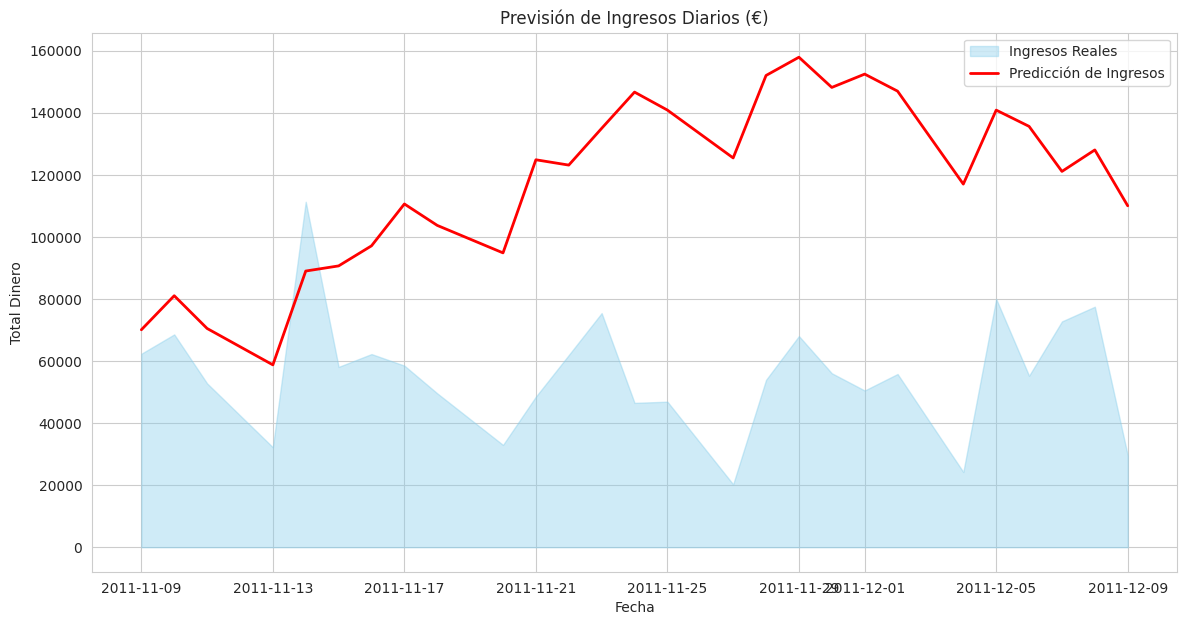

In [ ]:

target = 'daily_sales' # La columna que hemos creado al preprocesar datos
date_for_daily = 'date'

# Definimos el modelo avanzado
model_prophet_adv = Prophet(
  holidays=holidays,
  seasonality_mode='multiplicative',
  changepoint_prior_scale=0.1,        # Más flexible a cambios bruscos
  yearly_seasonality=True,
  weekly_seasonality=True,
  daily_seasonality=False
)

model_prophet, forecast, preds_prophet, df_test = train_predict_prophet(df_train, df_test, target, date_for_daily, model_prophet_adv)

# Modelo Prophet ADITIVO

📊 Métricas para Prophet:
   - MAE:  86505.10  (Error medio en dinero)
   - RMSE: 96776.81 (Sensible a grandes errores/outliers)
   - R2:   -25.3848  (Capacidad predictiva 0 a 1)
------------------------------
          date  actual_sales  predicted_sales  prediction_error
278 2011-11-09     62,359.13        70,401.20         -8,042.07
279 2011-11-10     68,593.52        79,649.57        -11,056.05
280 2011-11-11     52,808.40        74,905.82        -22,097.42
281 2011-11-13     32,213.29        70,491.74        -38,278.45
282 2011-11-14    111,348.61        93,750.05         17,598.56


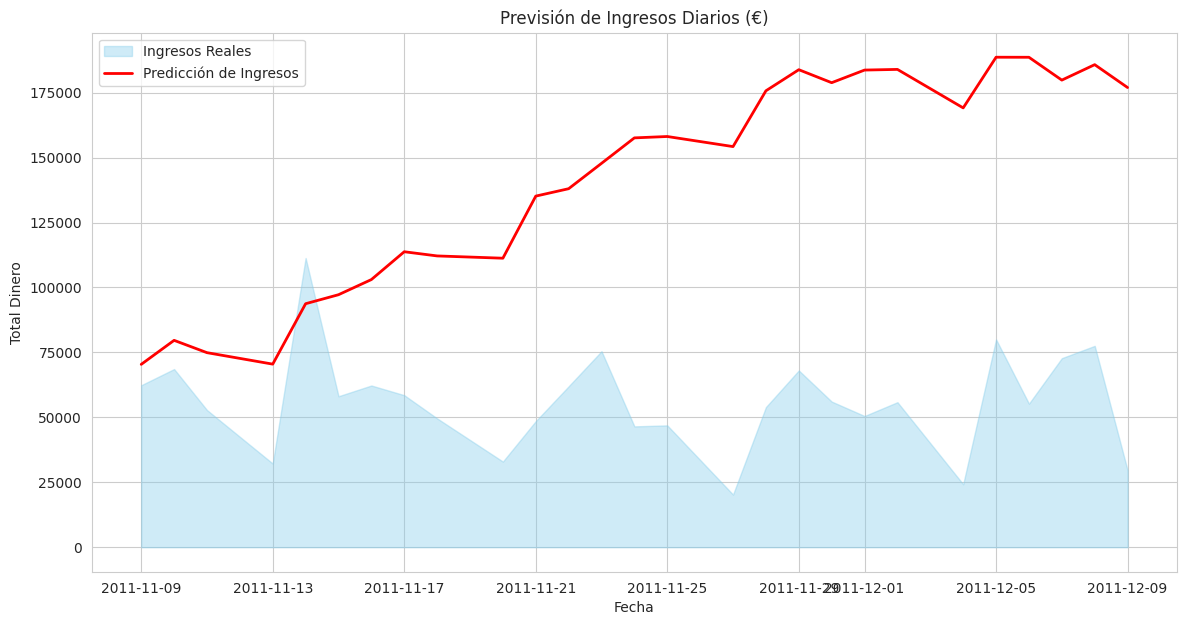

In [ ]:
# Definimos el modelo
model_prophet_aditive = Prophet(
  holidays=eventos_especiales,
  seasonality_mode='additive',
  changepoint_prior_scale=0.1,        # Más flexible a cambios bruscos
  yearly_seasonality=True,
  weekly_seasonality=True,
  daily_seasonality=False
)

model_prophet, forecast, preds_prophet, df_test = train_predict_prophet(df_train, df_test, target, date_for_daily, model_prophet_aditive)

In [ ]:
def train_predict_prophet_rescue(df_train, df_test, target, date, prophet_model, nombre_exp="Prophet"):
    # 1. Preparar datos (Prophet es estricto con los nombres)
    train_prophet = df_train.rename(columns={date: 'ds', target: 'y'})

    # NUEVA PARTE AÑADIDA: Crear el regresor de "memoria" (Lag 1)
    df_train_copy = df_train.copy()
    df_test_copy = df_test.copy()

    df_train_copy['sales_lag1'] = df_train_copy['daily_sales'].shift(1).fillna(method='bfill')
    df_test_copy['sales_lag1'] = df_test_copy['daily_sales'].shift(1).fillna(method='bfill')

    model = prophet_model

    # 3. ¡IMPORTANTE! Añadir el regresor antes del fit
    model.add_regressor('sales_lag1') # Changed model_rescue to model

    # 2. Entrenar
    model.fit(train_prophet.assign(sales_lag1=df_train_copy['sales_lag1'])) # Pass regressor to fit

    # 3. Predecir (le pasamos los días del dataframe de test)
    test_prophet = df_test_copy.rename(columns={date: 'ds'}) # Use df_test_copy
    forecast = model.predict(test_prophet[['ds', 'sales_lag1']]) # Pass the regressor to predict

    # El resultado está en la columna 'yhat'
    preds = forecast['yhat']

    # Create a modified df_test to add prediction columns
    df_test_modified = df_test.copy()
    df_test_modified['predicted_sales'] = preds.values # Corrected: Use .values to avoid index mismatch
    df_test_modified['actual_sales'] = df_test_modified[target] # Renombramos para claridad
    df_test_modified['prediction_error'] = df_test_modified['actual_sales'] - df_test_modified['predicted_sales']

    # --- PASO 3: Visualización y Métricas (Lo que viene después) ---

    # Metricas
    y_test = df_test_modified[target]

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"📊 Métricas para {nombre_exp}:")
    print(f"   - MAE:  {mae:.2f}  (Error medio en dinero)")
    print(f"   - RMSE: {rmse:.2f} (Sensible a grandes errores/outliers)")
    print(f"   - R2:   {r2:.4f}  (Capacidad predictiva 0 a 1)")
    print("-" * 30)

    # Use 'date' instead of 'InvoiceDate' for display and grouping
    print(df_test_modified[['date', 'actual_sales', 'predicted_sales', 'prediction_error']].head())

    # Agrupamos por día para ver el ingreso diario
    ingresos_diarios = df_test_modified.groupby(df_test_modified['date'].dt.date)[['actual_sales', 'predicted_sales']].sum()

    # Gráfica de Ingresos
    plt.figure(figsize=(14, 7))
    plt.fill_between(ingresos_diarios.index, ingresos_diarios['actual_sales'], color="skyblue", alpha=0.4, label='Ingresos Reales')
    plt.plot(ingresos_diarios.index, ingresos_diarios['predicted_sales'], color="red", lw=2, label='Predicción de Ingresos')
    plt.title("Previsión de Ingresos Diarios (€)")
    plt.xlabel("Fecha")
    plt.ylabel("Total Dinero")
    plt.legend()
    plt.show()

    return model, forecast, preds, df_test_modified

📊 Métricas para Prophet:
   - MAE:  12149.46  (Error medio en dinero)
   - RMSE: 17524.78 (Sensible a grandes errores/outliers)
   - R2:   0.1348  (Capacidad predictiva 0 a 1)
------------------------------
          date  actual_sales  predicted_sales  prediction_error
278 2011-11-09     62,359.13        53,807.85          8,551.28
279 2011-11-10     68,593.52        61,977.55          6,615.97
280 2011-11-11     52,808.40        54,297.38         -1,488.98
281 2011-11-13     32,213.29        39,686.73         -7,473.44
282 2011-11-14    111,348.61        57,064.17         54,284.44


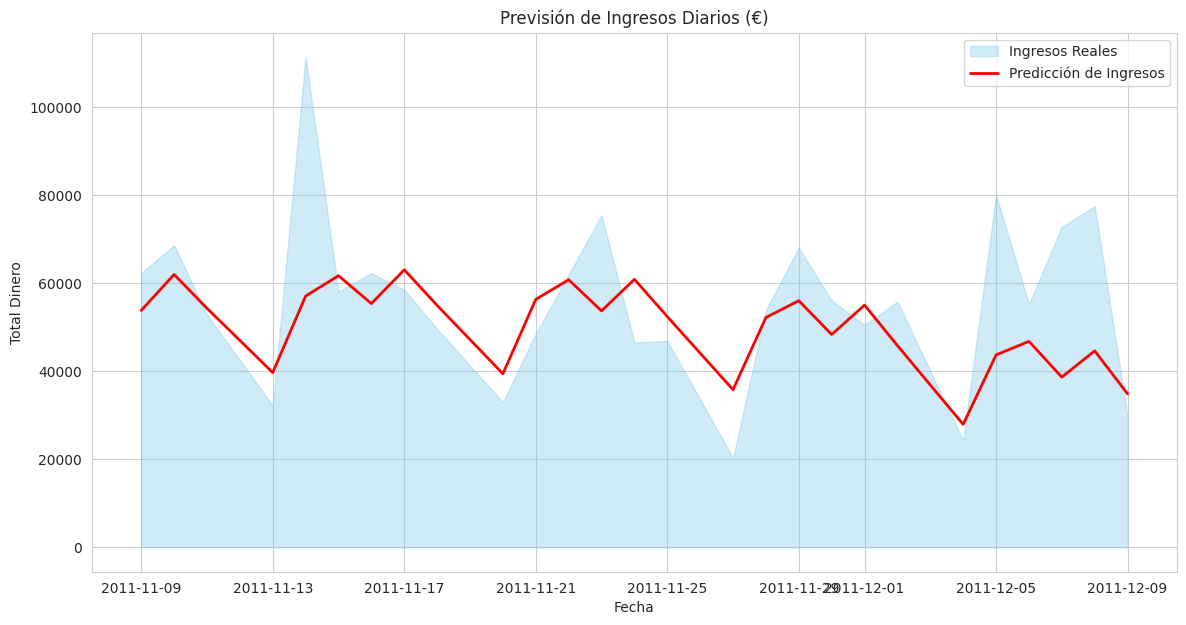

In [ ]:
model_rescue = Prophet(
    holidays=eventos_especiales,
    seasonality_mode='additive',   # Volvemos a aditivo ya que funciona mejor
    changepoint_prior_scale=0.01,   # Forzamos estabilidad
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)


model_prophet, forecast, preds_prophet, df_test = train_predict_prophet_rescue(df_train, df_test, target, date_for_daily, model_rescue)

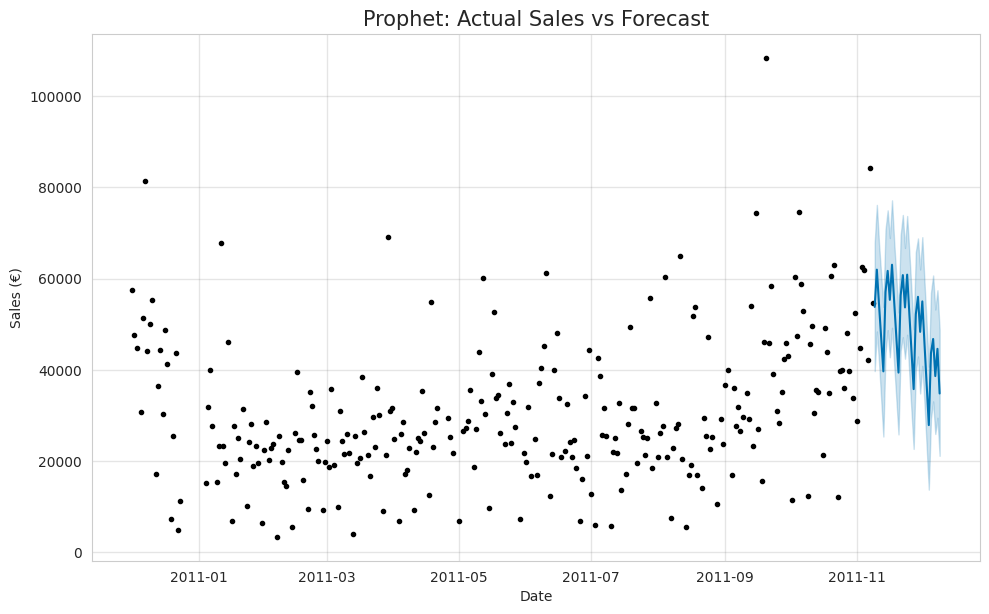

In [ ]:
from prophet.plot import plot_plotly, plot_components_plotly

# 1. Gráfico principal (Predicción con bandas de incertidumbre)
# Usamos objeto 'model_prophet' y dataframe de predicciones 'forecast'

# Gráfico estándar de Prophet (Matplotlib)
fig1 = model_prophet.plot(forecast)
plt.title("Prophet: Actual Sales vs Forecast", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Sales (€)")
plt.show()



2. Descomposición de Componentes (La "Caja Negra" abierta)
Esta es, para mí, la visualización más valiosa de Prophet. Te permite ver por separado:

  - Trend: La previsión de ventas general. En este caso la predicción para el próximo mes. (09-11-2011 a 09-12-2011)

  - Weekly: Qué días de la semana se factura más.

  - Yearly: Se pueden apreciar los picos estacionales (Black Friday, Navidad, verano, etc.).


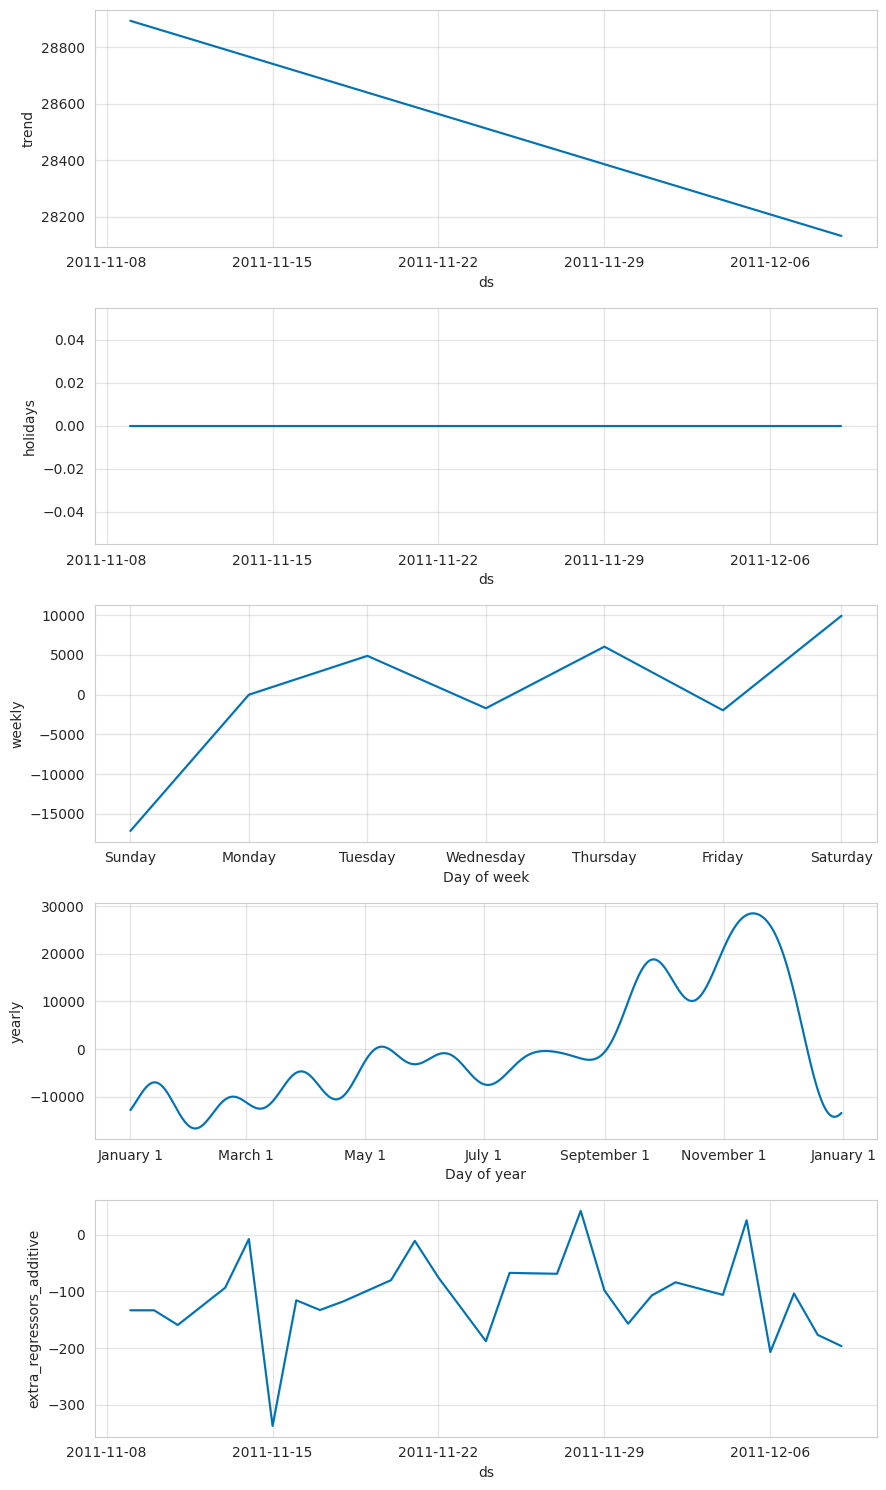

In [ ]:
# 2. Gráfico de Componentes (Tendencia y Estacionalidad)
fig2 = model_prophet.plot_components(forecast)
plt.show()

# TEST 2



In [ ]:
from prophet import Prophet

def train_prophet(
    df,
    changepoint_prior_scale,
    seasonality_prior_scale,
    seasonality_mode
):
    model = Prophet(
        growth='linear',
        changepoint_prior_scale=changepoint_prior_scale,
        seasonality_prior_scale=seasonality_prior_scale,
        seasonality_mode=seasonality_mode,
        weekly_seasonality=True,
        yearly_seasonality=True,
        daily_seasonality=False
    )

    # Estacionalidad mensual (muy útil en e-commerce)
    model.add_seasonality(
        name='monthly',
        period=30.5,
        fourier_order=5
    )

    model.fit(df)

    return model

## Modelo A (baseline robusto)

In [ ]:
train = df_train

target = 'daily_sales' # La columna que hemos creado al preprocesar datos
date_for_daily = 'date'

train = df_train.rename(columns={date_for_daily: 'ds', target: 'y'})

model_A = train_prophet(
    train,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    seasonality_mode='additive'
)

## Modelo B (captura picos de ventas)

In [ ]:
model_B = train_prophet(
    train,
    changepoint_prior_scale=0.3,
    seasonality_prior_scale=15,
    seasonality_mode='multiplicative'
)

## Modelo C (regularizado, evita sobreajuste)

In [ ]:
model_C = train_prophet(
    train,
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=5,
    seasonality_mode='additive'
)

## Modelo D (equilibrado, normalmente ganador en e-commerce)

In [ ]:
model_D = train_prophet(
    train,
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=10,
    seasonality_mode='multiplicative'
)

# ----- Validación con backtesting (solo TRAIN) -------

Usaremos cross_validation

In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics

def validate_model(model):

    df_cv = cross_validation(
        model,
        initial='250 days',
        period='30 days',
        horizon='30 days'
    )

    df_perf = performance_metrics(df_cv)

    return df_perf

## Evaluar modelos

In [ ]:
models = {
    "A": model_A,
    "B": model_B,
    "C": model_C,
    "D": model_D
}

results = {}

for name, model in models.items():
    perf = validate_model(model)
    results[name] = perf['rmse'].mean()

print(results)

INFO:prophet:Making 3 forecasts with cutoffs between 2011-08-10 00:00:00 and 2011-10-09 00:00:00


  0%|          | 0/3 [00:00<?, ?it/s]

INFO:prophet:Making 3 forecasts with cutoffs between 2011-08-10 00:00:00 and 2011-10-09 00:00:00


  0%|          | 0/3 [00:00<?, ?it/s]

INFO:prophet:Making 3 forecasts with cutoffs between 2011-08-10 00:00:00 and 2011-10-09 00:00:00


  0%|          | 0/3 [00:00<?, ?it/s]

INFO:prophet:Making 3 forecasts with cutoffs between 2011-08-10 00:00:00 and 2011-10-09 00:00:00


  0%|          | 0/3 [00:00<?, ?it/s]

{'A': np.float64(29746.79458355603), 'B': np.float64(36685.12301508144), 'C': np.float64(27916.010834058605), 'D': np.float64(25041.615884109564)}


# ----------  Selección del mejor modelo -------

In [ ]:
best_model_name = min(results, key=results.get)
best_model = models[best_model_name]

print("Best model:", best_model_name)

Best model: D


# ------ Predicción en TEST (lo importante) ------

Ahora sí usamos el periodo real que definimos:

In [ ]:
future = best_model.make_future_dataframe(periods=31)

forecast = best_model.predict(future)

## Filtrar solo periodo de test

In [ ]:
forecast_test = forecast[
    (forecast['ds'] >= '2011-11-09') &
    (forecast['ds'] <= '2011-12-09')
]

# ------ Evaluacion final (TEST REAL)

📊 Métricas para Prophet elegido:
   - MAE:  21,586.03  (Error medio en dinero)
   - RMSE: 24,457.88 (Sensible a grandes errores/outliers)
   - R2:   -0.6852  (Capacidad predictiva 0 a 1)
------------------------------
        date  actual_sales  predicted_sales  prediction_error
0 2011-11-09     62,359.13        65,143.91         -2,784.78
1 2011-11-10     68,593.52        77,002.90         -8,409.38
2 2011-11-11     52,808.40        67,220.78        -14,412.38
3 2011-11-13     32,213.29        47,671.11        -15,457.82
4 2011-11-14    111,348.61        69,563.66         41,784.95


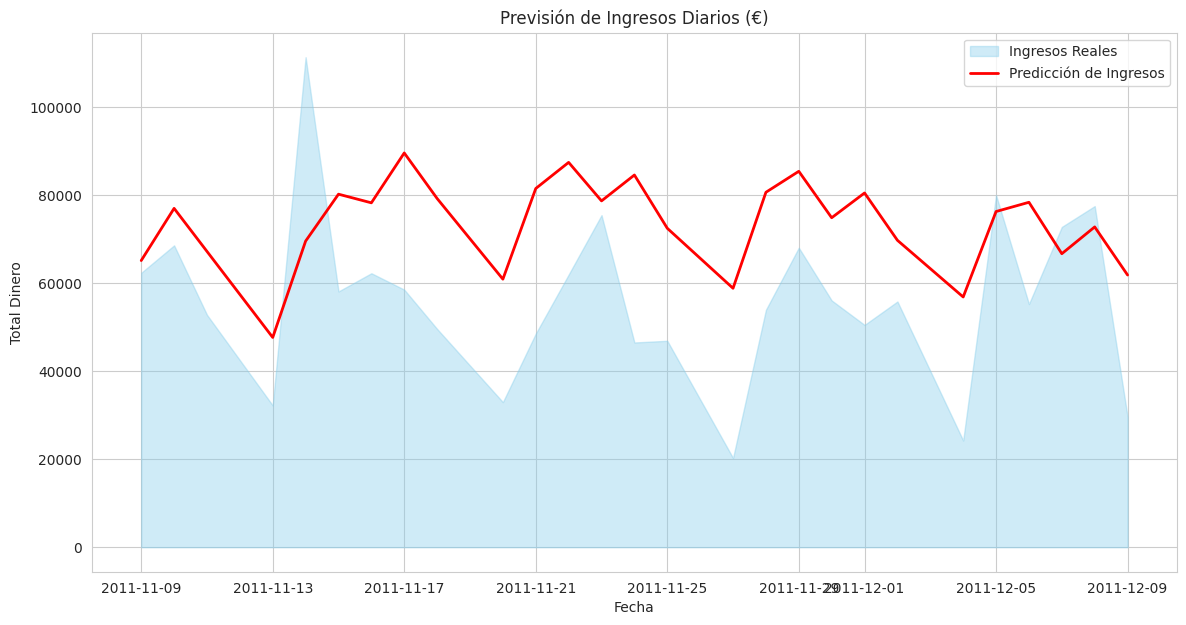

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def evaluate_test(forecast_test, test):

    # Merge forecast_test (with 'ds', 'yhat') with test (with 'date', 'daily_sales')
    # We need to explicitly map the date columns for merging and the target column for evaluation.
    df_eval = forecast_test[['ds', 'yhat']].merge(test[['date', 'daily_sales']], left_on='ds', right_on='date')

    # Rename columns for clarity and calculate prediction error
    df_eval = df_eval.rename(columns={'daily_sales': 'actual_sales', 'yhat': 'predicted_sales'})
    df_eval['prediction_error'] = df_eval['actual_sales'] - df_eval['predicted_sales']


    mae = mean_absolute_error(df_eval['actual_sales'], df_eval['predicted_sales'])
    rmse = np.sqrt(mean_squared_error(df_eval['actual_sales'], df_eval['predicted_sales']))
    r2 = r2_score(df_eval['actual_sales'], df_eval['predicted_sales'])

    print(f"📊 Métricas para Prophet elegido:")
    print(f"   - MAE:  {mae:,.2f}  (Error medio en dinero)")
    print(f"   - RMSE: {rmse:,.2f} (Sensible a grandes errores/outliers)")
    print(f"   - R2:   {r2:.4f}  (Capacidad predictiva 0 a 1)")
    print("-" * 30)

    # Use 'date' instead of 'InvoiceDate' for display and grouping
    print(df_eval[['date', 'actual_sales', 'predicted_sales', 'prediction_error']].head())

    # Agrupamos por día para ver el ingreso diario
    ingresos_diarios = df_eval.groupby(df_eval['date'].dt.date)[['actual_sales', 'predicted_sales']].sum()

    # Gráfica de Ingresos
    plt.figure(figsize=(14, 7))
    plt.fill_between(ingresos_diarios.index, ingresos_diarios['actual_sales'], color="skyblue", alpha=0.4, label='Ingresos Reales')
    plt.plot(ingresos_diarios.index, ingresos_diarios['predicted_sales'], color="red", lw=2, label='Predicción de Ingresos')
    plt.title("Previsión de Ingresos Diarios (€)")
    plt.xlabel("Fecha")
    plt.ylabel("Total Dinero")
    plt.legend()
    plt.show()

    return mae, rmse, df_eval

mae, rmse, df_eval = evaluate_test(forecast_test, df_test)


# Exportar mejor modelo / resultados de test en un .csv

Realizamos la exportación al final del proceso, justo después de haber generado las predicciones sobre el conjunto de test (df_test)

Para la resta final, solo necesitas dos piezas de información:

- `ds`: La fecha (para que el ordenador sepa qué día restar con qué día).

- `yhat`: El valor que tu modelo ha predicho.


Una vez tengas los dos archivos CSV, creamos un tercer notebook para realizar la operación final

📊 Métricas para Prophet:
   - MAE:  11352.57  (Error medio en dinero)
   - RMSE: 16338.66 (Sensible a grandes errores/outliers)
   - R2:   0.2480  (Capacidad predictiva 0 a 1)
------------------------------
          date  actual_sales  predicted_sales  prediction_error
278 2011-11-09     62,359.13        57,026.81          5,332.32
279 2011-11-10     68,593.52        61,232.42          7,361.10
280 2011-11-11     52,808.40        51,845.43            962.97
281 2011-11-13     32,213.29        37,219.39         -5,006.10
282 2011-11-14    111,348.61        55,855.24         55,493.37


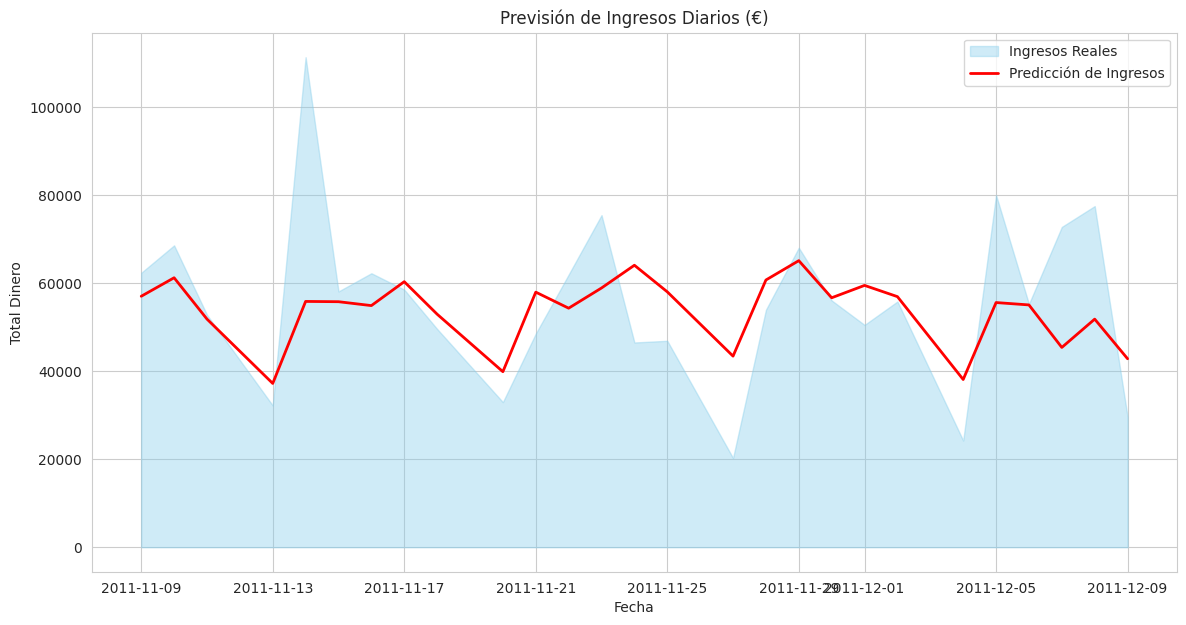

,date,daily_sales,month,day_of_month,day_of_week,is_weekend,sales_lag_1,sales_lag_7,rolling_mean_7,rolling_mean_30,trend_1_vs_7,predicted_sales,actual_sales,prediction_error
278,2011-11-09,"62,359.13",11,9,2,0,"54,617.93","28,809.90","54,135.51","44,988.83","25,808.03","57,026.81","62,359.13","5,332.32"
279,2011-11-10,"68,593.52",11,10,3,0,"62,359.13","44,826.29","58,928.26","44,577.92","17,532.84","61,232.42","68,593.52","7,361.10"
280,2011-11-11,"52,808.40",11,11,4,0,"68,593.52","62,590.96","62,323.57","44,902.26","6,002.56","51,845.43","52,808.40",962.97
281,2011-11-13,"32,213.29",11,13,6,1,"52,808.40","61,799.62","60,926.07","44,900.69","-8,991.22","37,219.39","32,213.29","-5,006.10"
282,2011-11-14,"111,348.61",11,14,0,0,"32,213.29","42,153.85","56,699.45","45,565.36","-9,940.56","55,855.24","111,348.61","55,493.37"
283,2011-11-15,"58,121.76",11,15,1,0,"111,348.61","84,150.01","66,584.41","47,756.21","27,198.60","55,792.05","58,121.76","2,329.71"
284,2011-11-16,"62,258.29",11,16,2,0,"58,121.76","54,617.93","62,866.09","48,035.99","3,503.83","54,907.84","62,258.29","7,350.45"
285,2011-11-17,"58,531.66",11,17,3,0,"62,258.29","62,359.13","63,957.57","49,096.03",-100.84,"60,341.19","58,531.66","-1,809.53"
286,2011-11-18,"49,595.48",11,18,4,0,"58,531.66","68,593.52","63,410.79","49,857.49","-10,061.86","52,954.71","49,595.48","-3,359.23"
287,2011-11-20,"32,971.76",11,20,6,1,"49,595.48","52,808.40","60,696.78","50,341.92","-3,212.92","39,888.53","32,971.76","-6,916.77"


Predicciones exportadas correctamente a: /content/sample_data/prediccion_test_ventas.csv


In [ ]:

target = 'daily_sales' # La columna que hemos creado al preprocesar datos
date_for_daily = 'date'

# Mejor modelo
model_prophet_aditive = Prophet(
  #holidays=eventos_especiales,
  seasonality_mode='additive',
  changepoint_prior_scale=0.1,   # Más flexible a cambios bruscos
  yearly_seasonality=True,
  weekly_seasonality=True,
  daily_seasonality=False
)



best_model_prophet, forecast, preds_prophet, df_test = train_predict_prophet(df_train, df_test, target, date_for_daily, model_prophet_aditive)

display(df_test)

path_predictions_csv = '/content/sample_data/prediccion_test_ventas.csv'

df_test.to_csv(path_predictions_csv, index=False)
print(f"Predicciones exportadas correctamente a: {path_predictions_csv}")


--- 3. EVALUACIÓN Y VISUALIZACIÓN DEL MES DE TEST con time series split ---
          date  daily_sales  month  day_of_month  day_of_week  is_weekend  sales_lag_1  sales_lag_7  rolling_mean_7  \
278 2011-11-09    62,359.13     11             9            2           0    54,617.93    28,809.90       54,135.51   
279 2011-11-10    68,593.52     11            10            3           0    62,359.13    44,826.29       58,928.26   
280 2011-11-11    52,808.40     11            11            4           0    68,593.52    62,590.96       62,323.57   
281 2011-11-13    32,213.29     11            13            6           1    52,808.40    61,799.62       60,926.07   
282 2011-11-14   111,348.61     11            14            0           0    32,213.29    42,153.85       56,699.45   

     rolling_mean_30  trend_1_vs_7  predicted_sales  actual_sales  prediction_error  
278        44,988.83     25,808.03        57,026.81     62,359.13          5,332.32  
279        44,577.92     17,532.84  

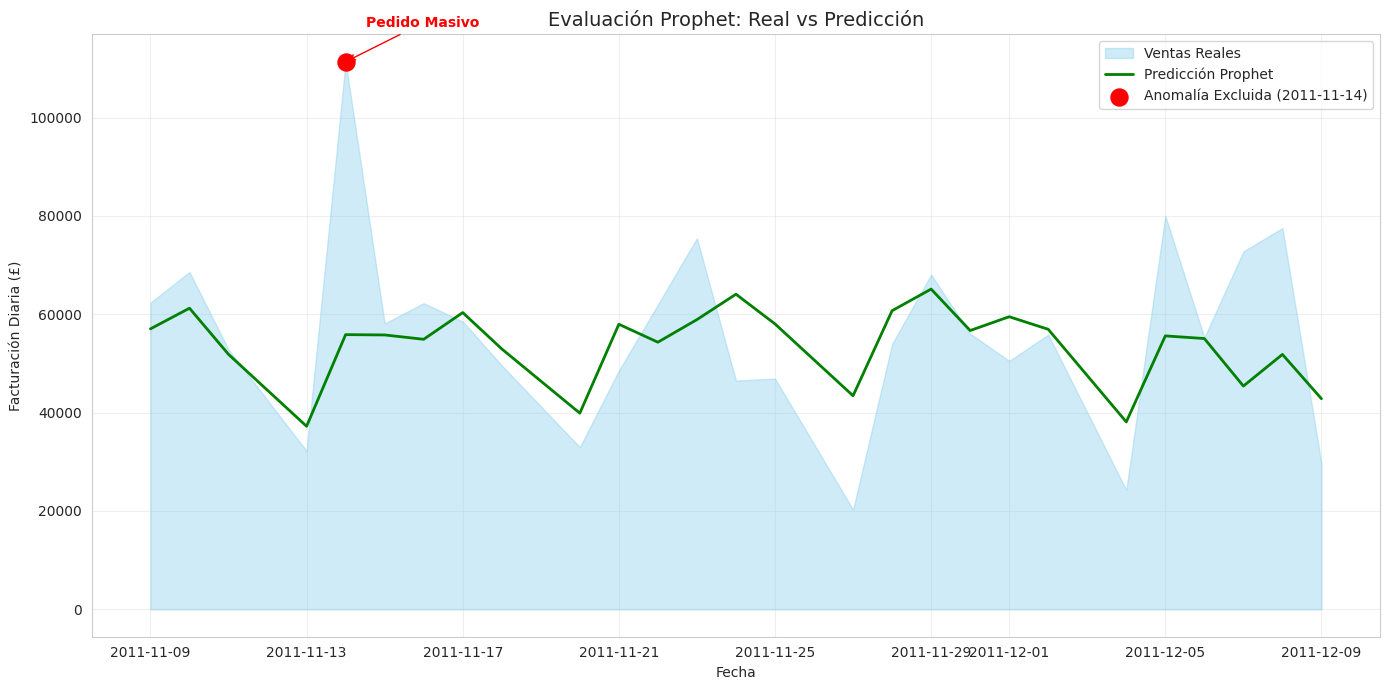

In [ ]:
print("\n--- 3. EVALUACIÓN Y VISUALIZACIÓN DEL MES DE TEST con time series split ---")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_prophet_with_transparency(df_test):
    """
    Adaptación de evaluación para Prophet.
    df_test: El dataframe de test que ya contiene 'date', 'daily_sales', 'actual_sales', 'predicted_sales'.
    """

    print(df_test.head())

    # 2. Preparamos el dataframe de evaluación
    # df_test already contains 'actual_sales' and 'predicted_sales' from train_predict_prophet
    df_eval = df_test.copy()

    # Ensure 'date' column is datetime type for plotting
    df_eval['date'] = pd.to_datetime(df_eval['date'])

    # Use existing 'actual_sales' and 'predicted_sales' columns
    # Recalculate prediction_error based on these columns
    df_eval['prediction_error'] = df_eval['actual_sales'] - df_eval['predicted_sales']

    # ESCENARIO A: TEST COMPLETO
    mae_full = mean_absolute_error(df_eval['actual_sales'], df_eval['predicted_sales'])
    rmse_full = np.sqrt(mean_squared_error(df_eval['actual_sales'], df_eval['predicted_sales']))
    r2_full = r2_score(df_eval['actual_sales'], df_eval['predicted_sales'])

    print("\n[ ESCENARIO A ] MÉTRICAS CON EL TEST COMPLETO (Incluyendo 14-Nov)")
    print(f"   - MAE:  £{mae_full:,.2f}")
    print(f"   - RMSE: £{rmse_full:,.2f}")
    print(f"   - R2:   {r2_full:.4f}")

    # ESCENARIO B: EXCLUSIÓN DE VENTAS AL POR MAYOR (14 de Noviembre)
    fecha_anomala = '2011-11-14'
    # Filtramos comparando strings de fecha
    df_eval_corregido = df_eval[df_eval['date'].dt.strftime('%Y-%m-%d') != fecha_anomala]

    mae_corr = mean_absolute_error(df_eval_corregido['actual_sales'], df_eval_corregido['predicted_sales'])
    rmse_corr = np.sqrt(mean_squared_error(df_eval_corregido['actual_sales'], df_eval_corregido['predicted_sales']))
    r2_corr = r2_score(df_eval_corregido['actual_sales'], df_eval_corregido['predicted_sales'])

    print(f"\n[ ESCENARIO B ] MÉTRICAS CORREGIDAS (Excluyendo pedido mayorista del {fecha_anomala})")
    print(f"   - MAE:  £{mae_corr:,.2f}  (Mejora de £{mae_full - mae_corr:,.2f})")
    print(f"   - RMSE: £{rmse_corr:,.2f}  (Mejora de £{rmse_full - rmse_corr:,.2f})")
    print(f"   - R2:   {r2_corr:.4f}")
    print("-" * 80)


    #Exportar a CSV
    path_predictions_csv = '/content/sample_data/prediccion_test_ventas-excluido-pico-ventas.csv'
    df_eval_corregido.to_csv(path_predictions_csv, index=False)
    print(f"Predicciones exportadas correctamente a: {path_predictions_csv}")

    # VISUALIZACIÓN
    plt.figure(figsize=(14, 7))

    # Pintamos la realidad y la predicción
    plt.fill_between(df_eval['date'], df_eval['actual_sales'], color="skyblue", alpha=0.4, label='Ventas Reales')
    plt.plot(df_eval['date'], df_eval['predicted_sales'], color="green", lw=2, label='Predicción Prophet')

    # DESTACAMOS LA ANOMALÍA
    venta_anomala = df_eval[df_eval['date'].dt.strftime('%Y-%m-%d') == fecha_anomala]
    if not venta_anomala.empty:
        plt.scatter(venta_anomala['date'], venta_anomala['actual_sales'],
                    color='red', s=150, zorder=5, label=f'Anomalía Excluida ({fecha_anomala})')
        plt.annotate('Pedido Masivo',
                     xy=(venta_anomala['date'].iloc[0], venta_anomala['actual_sales'].iloc[0]),
                     xytext=(15, 25), textcoords='offset points',
                     color='red', fontweight='bold', arrowprops=dict(arrowstyle='->', color='red'))

    plt.title("Evaluación Prophet: Real vs Predicción", fontsize=14)
    plt.xlabel("Fecha")
    plt.ylabel("Facturación Diaria (£)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_eval, df_eval_corregido


df_eval, df_eval_corregido = evaluate_prophet_with_transparency(df_test)

# Correlacion mapa


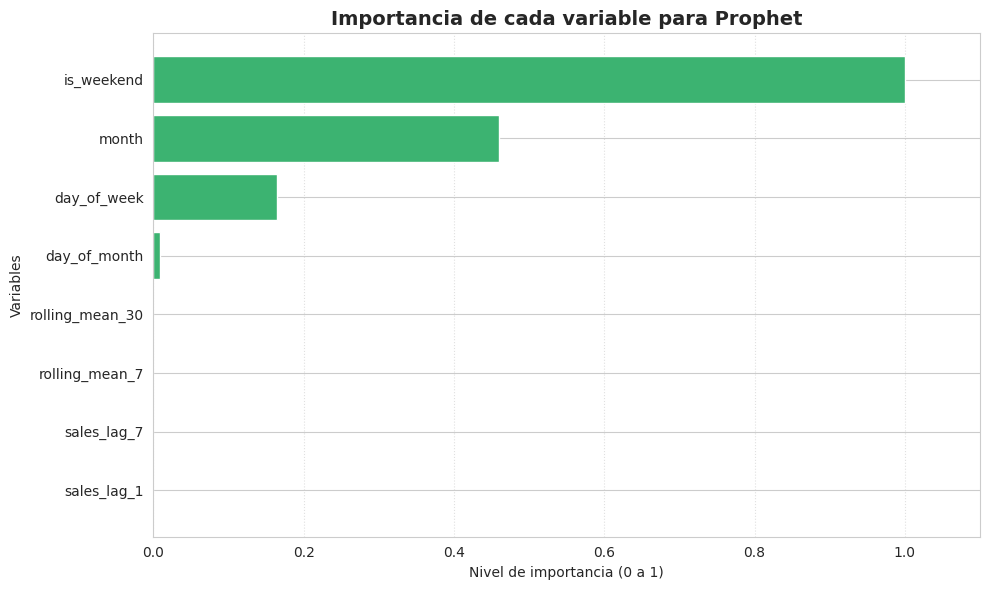

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet.utilities import regressor_coefficients

def plot_prophet_importance_normalized(model):
    # 1. Extraer los coeficientes
    coefs = regressor_coefficients(model)

    # 2. Tomamos el valor absoluto (impacto total)
    df_importances = pd.DataFrame({
        'Variable': coefs['regressor'],
        'Impacto_Bruto': coefs['coef'].abs()
    })

    # 3. NORMALIZACIÓN de 0 a 1
    # Esto hace que la variable más potente valga 1 y el resto se escalen proporcionalmente
    max_val = df_importances['Impacto_Bruto'].max()
    min_val = df_importances['Impacto_Bruto'].min()

    # Evitamos división por cero si todos los coeficientes fueran iguales
    if max_val != min_val:
        df_importances['Importancia_Normalizada'] = (df_importances['Impacto_Bruto'] - min_val) / (max_val - min_val)
    else:
        df_importances['Importancia_Normalizada'] = 1.0

    # Ordenamos para la gráfica
    df_importances = df_importances.sort_values(by='Importancia_Normalizada', ascending=True)

    # 4. Gráfico
    plt.figure(figsize=(10, 6))
    bars = plt.barh(df_importances['Variable'], df_importances['Importancia_Normalizada'], color='mediumseagreen')

    # Añadimos etiquetas con el valor exacto al final de cada barra para mayor claridad
    #for bar in bars:
     #   plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
      #           f'{bar.get_width():.4f}', va='center', ha='left', fontsize=10)

    plt.title("Importancia de cada variable para Prophet", fontsize=14, fontweight='bold')
    plt.xlabel("Nivel de importancia (0 a 1)")
    plt.ylabel("Variables")
    plt.xlim(0, 1.1) # Damos espacio para el texto de las etiquetas
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()



plot_prophet_importance_normalized(best_model_prophet)